<a href="https://colab.research.google.com/github/mahim83/Deep-Learning-Assignments-certificates/blob/main/Assignment4__Implement_backpropagation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import zipfile
import pandas as pd

# Extract the zip file
with zipfile.ZipFile('/content/abalone (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Define column names
column_names = [
    'Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
    'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'
]

# Load the dataset, assuming the extracted file is named 'abalone.data'
df = pd.read_csv('/content/abalone.data', header=None, names=column_names)

# Display the first few rows of the DataFrame
print("First 5 rows of the Abalone dataset:")
print(df.head())

# Display information about the DataFrame
print("\nDataFrame Info:")
print(df.info())

First 5 rows of the Abalone dataset:
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        41

In [2]:
import numpy as np

# 1. Add a new column named 'Age' by adding 1.5 to the 'Rings' column
df['Age'] = df['Rings'] + 1.5

# 2. Drop the original 'Rings' column
df = df.drop('Rings', axis=1)

print("DataFrame after adding 'Age' and dropping 'Rings':")
print(df.head())

DataFrame after adding 'Age' and dropping 'Rings':
  Sex  Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight   Age  
0         0.150  16.5  
1         0.070   8.5  
2         0.210  10.5  
3         0.155  11.5  
4         0.055   8.5  


In [3]:
print("\nMissing values before handling:\n", df.isnull().sum())

# Perform one-hot encoding on the 'Sex' column
df = pd.get_dummies(df, columns=['Sex'], prefix='Sex')

print("\nDataFrame after one-hot encoding 'Sex' column:")
print(df.head())


Missing values before handling:
 Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Age               0
dtype: int64

DataFrame after one-hot encoding 'Sex' column:
   Length  Diameter  Height  Whole_weight  Shucked_weight  Viscera_weight  \
0   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell_weight   Age  Sex_F  Sex_I  Sex_M  
0         0.150  16.5  False  False   True  
1         0.070   8.5  False  False   True  
2         0.210  10.5   True  False  False  
3         0.155  11.5  False  False   True  
4         0.055   8.5  False   True  

In [4]:
import numpy as np

# 5. Separate features (X) and target (y)
X = df.drop('Age', axis=1)
y = df['Age']

# Convert boolean columns to integer (0 or 1) for numerical processing
X['Sex_F'] = X['Sex_F'].astype(int)
X['Sex_I'] = X['Sex_I'].astype(int)
X['Sex_M'] = X['Sex_M'].astype(int)

# 6. Identify numerical feature columns in X (all columns except 'Age' are now features, including one-hot encoded 'Sex' which are effectively numerical)
numerical_cols = X.columns.tolist()

# 7. Implement Min-Max scaling manually for numerical features in X
# Create a copy to avoid SettingWithCopyWarning
X_scaled = X.copy()

for col in numerical_cols:
    min_val = X_scaled[col].min()
    max_val = X_scaled[col].max()
    # Avoid division by zero if all values are the same (range is 0)
    if (max_val - min_val) != 0:
        X_scaled[col] = (X_scaled[col] - min_val) / (max_val - min_val)
    else:
        X_scaled[col] = 0 # If range is 0, all values are the same, so scale to 0

print(
    "\nFirst 5 rows of features (X_scaled) after Min-Max scaling and target (y):"
)
print("X_scaled:")
print(X_scaled.head())
print("\ny:")
print(y.head())


First 5 rows of features (X_scaled) after Min-Max scaling and target (y):
X_scaled:
     Length  Diameter    Height  Whole_weight  Shucked_weight  Viscera_weight  \
0  0.513514  0.521008  0.084071      0.181335        0.150303        0.132324   
1  0.371622  0.352941  0.079646      0.079157        0.066241        0.063199   
2  0.614865  0.613445  0.119469      0.239065        0.171822        0.185648   
3  0.493243  0.521008  0.110619      0.182044        0.144250        0.149440   
4  0.344595  0.336134  0.070796      0.071897        0.059516        0.051350   

   Shell_weight  Sex_F  Sex_I  Sex_M  
0      0.147982    0.0    0.0    1.0  
1      0.068261    0.0    0.0    1.0  
2      0.207773    1.0    0.0    0.0  
3      0.152965    0.0    0.0    1.0  
4      0.053313    0.0    1.0    0.0  

y:
0    16.5
1     8.5
2    10.5
3    11.5
4     8.5
Name: Age, dtype: float64


In [5]:
X_np = X_scaled.to_numpy()
y_np = y.to_numpy().reshape(-1, 1)

# Combine X and y for shuffling
data = np.concatenate((X_np, y_np), axis=1)

# Shuffle the data
np.random.seed(42) # For reproducibility
np.random.shuffle(data)

# Split X and y back
X_shuffled = data[:, :-1]
y_shuffled = data[:, -1].reshape(-1, 1)

# Define split ratio (e.g., 80% train, 20% test)
split_ratio = 0.8
split_index = int(len(X_shuffled) * split_ratio)

X_train = X_shuffled[:split_index]
X_test = X_shuffled[split_index:]
y_train = y_shuffled[:split_index]
y_test = y_shuffled[split_index:]

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (3341, 10)
Shape of X_test: (836, 10)
Shape of y_train: (3341, 1)
Shape of y_test: (836, 1)


In [6]:
import numpy as np

# 1. Determine the number of input features
input_size = X_train.shape[1]

# 2. Define the number of units for the hidden layer
hidden_size = 64 # Example hidden layer size

# 3. Define the number of output units
output_size = 1 # Regression task, single output

# 4. Initialize weights for the first layer (input to hidden)
# Scaling by np.sqrt(1/input_size) for better initialization (He initialization variant for ReLU, or Xavier for tanh/sigmoid)
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1/input_size)

# 5. Initialize biases for the hidden layer
b1 = np.zeros((1, hidden_size))

# 6. Initialize weights for the second layer (hidden to output)
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1/hidden_size)

# 7. Initialize biases for the output layer
b2 = np.zeros((1, output_size))

# 8. Store these initialized weights and biases (already stored as W1, b1, W2, b2)
print("Neural Network Architecture Defined and Initialized:")
print(f"Input Layer Size: {input_size}")
print(f"Hidden Layer Size: {hidden_size}")
print(f"Output Layer Size: {output_size}")
print(f"Shape of W1 (Input to Hidden Weights): {W1.shape}")
print(f"Shape of b1 (Hidden Layer Biases): {b1.shape}")
print(f"Shape of W2 (Hidden to Output Weights): {W2.shape}")
print(f"Shape of b2 (Output Layer Biases): {b2.shape}")

Neural Network Architecture Defined and Initialized:
Input Layer Size: 10
Hidden Layer Size: 64
Output Layer Size: 1
Shape of W1 (Input to Hidden Weights): (10, 64)
Shape of b1 (Hidden Layer Biases): (1, 64)
Shape of W2 (Hidden to Output Weights): (64, 1)
Shape of b2 (Output Layer Biases): (1, 1)


In [7]:
import numpy as np

# 1. ReLU activation function
def relu(x):
    return np.maximum(0, x)

# 2. Derivative of ReLU
def relu_derivative(x):
    return (x > 0).astype(float)

# 3. Sigmoid activation function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# 4. Derivative of Sigmoid
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

# 5. Mean Squared Error (MSE) loss function
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

# 6. Derivative of MSE
def mse_derivative(y_true, y_pred):
    return 2 * (y_pred - y_true) / y_true.size

print("Activation functions and loss function with their derivatives defined.")

Activation functions and loss function with their derivatives defined.


In [8]:
import numpy as np

def forward_propagation(X, W1, b1, W2, b2):
    # Hidden layer calculations
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)  # Apply ReLU activation

    # Output layer calculations
    Z2 = np.dot(A1, W2) + b2
    A2 = Z2  # No activation for output layer in regression

    return Z1, A1, Z2, A2

# Test the forward_propagation function with X_train
# Ensure W1, b1, W2, b2, and relu function are available from previous steps

Z1, A1, Z2, A2 = forward_propagation(X_train, W1, b1, W2, b2)

print("Shape of Z1:", Z1.shape)
print("Shape of A1:", A1.shape)
print("Shape of Z2:", Z2.shape)
print("Shape of A2 (final output):", A2.shape)


Shape of Z1: (3341, 64)
Shape of A1: (3341, 64)
Shape of Z2: (3341, 1)
Shape of A2 (final output): (3341, 1)


In [9]:
import numpy as np

def backward_propagation(X, y_true, Z1, A1, A2, W2):
    m = y_true.shape[0] # Number of samples

    # 1. Calculate the derivative of the loss with respect to the output layer's weighted sum (dZ2)
    # Reshape y_true to match A2's shape for element-wise operations
    dZ2 = mse_derivative(y_true, A2) * m # Multiply by m because mse_derivative already divides by y_true.size (m*output_size)

    # 2. Calculate the gradient for the output layer's weights (dW2)
    dW2 = np.dot(A1.T, dZ2)

    # 3. Calculate the gradient for the output layer's biases (db2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # 4. Calculate the derivative of the loss with respect to the hidden layer's activation (dA1)
    dA1 = np.dot(dZ2, W2.T)

    # 5. Calculate the derivative of the loss with respect to the hidden layer's weighted sum (dZ1)
    dZ1 = dA1 * relu_derivative(Z1)

    # 6. Calculate the gradient for the hidden layer's weights (dW1)
    dW1 = np.dot(X.T, dZ1)

    # 7. Calculate the gradient for the hidden layer's biases (db1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Test the backward_propagation function with X_train and y_train
# Ensure Z1, A1, A2, W2, mse_derivative, relu_derivative are available from previous steps

dW1, db1, dW2, db2 = backward_propagation(X_train, y_train, Z1, A1, A2, W2)

print("Backward Propagation Gradients Shapes:")
print(f"Shape of dW1: {dW1.shape}")
print(f"Shape of db1: {db1.shape}")
print(f"Shape of dW2: {dW2.shape}")
print(f"Shape of db2: {db2.shape}")

Backward Propagation Gradients Shapes:
Shape of dW1: (10, 64)
Shape of db1: (1, 64)
Shape of dW2: (64, 1)
Shape of db2: (1, 1)


In [10]:
import numpy as np

# 1. Define the number of training epochs and the learning rate
epochs = 1000
learning_rate = 0.01

# 2. Use previously initialized W1, b1, W2, b2 from the 'Implement Neural Network Architecture' subtask
# No re-initialization needed as they are already in the kernel state.

# Keep track of loss for plotting (optional)
loss_history = []

# 3. Create a training loop
for epoch in range(epochs):
    # 4a. Perform forward propagation
    Z1, A1, Z2, A2 = forward_propagation(X_train, W1, b1, W2, b2)

    # 4b. Calculate the Mean Squared Error (MSE) loss
    current_loss = mse(y_train, A2)
    loss_history.append(current_loss)

    # Optionally print loss every few epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {current_loss:.4f}")

    # 4c. Perform backward propagation
    dW1, db1, dW2, db2 = backward_propagation(X_train, y_train, Z1, A1, A2, W2)

    # 4d. Update the weights and biases using gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

print("Training complete.")

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_238/1692948049.py:22: RuntimeWarning: overflow encountered in square
  return np.mean((y_true - y_pred)**2)


Epoch 100/1000, Loss: inf


/tmp/ipykernel_238/1996516785.py:20: RuntimeWarning: invalid value encountered in multiply
  dZ1 = dA1 * relu_derivative(Z1)


Epoch 200/1000, Loss: nan
Epoch 300/1000, Loss: nan
Epoch 400/1000, Loss: nan
Epoch 500/1000, Loss: nan
Epoch 600/1000, Loss: nan
Epoch 700/1000, Loss: nan
Epoch 800/1000, Loss: nan
Epoch 900/1000, Loss: nan
Epoch 1000/1000, Loss: nan
Training complete.


In [11]:
import numpy as np

def backward_propagation(X, y_true, Z1, A1, A2, W2):
    m = y_true.shape[0] # Number of samples

    # 1. Calculate the derivative of the loss with respect to the output layer's weighted sum (dZ2)
    # The mse_derivative function already returns the average gradient (divided by m).
    # Reshape y_true to match A2's shape for element-wise operations
    dZ2 = mse_derivative(y_true, A2)

    # 2. Calculate the gradient for the output layer's weights (dW2)
    dW2 = np.dot(A1.T, dZ2)

    # 3. Calculate the gradient for the output layer's biases (db2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    # 4. Calculate the derivative of the loss with respect to the hidden layer's activation (dA1)
    dA1 = np.dot(dZ2, W2.T)

    # 5. Calculate the derivative of the loss with respect to the hidden layer's weighted sum (dZ1)
    dZ1 = dA1 * relu_derivative(Z1)

    # 6. Calculate the gradient for the hidden layer's weights (dW1)
    dW1 = np.dot(X.T, dZ1)

    # 7. Calculate the gradient for the hidden layer's biases (db1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2

# Test the backward_propagation function with X_train and y_train
# Ensure Z1, A1, A2, W2, mse_derivative, relu_derivative are available from previous steps

dW1, db1, dW2, db2 = backward_propagation(X_train, y_train, Z1, A1, A2, W2)

print("Backward Propagation Gradients Shapes:")
print(f"Shape of dW1: {dW1.shape}")
print(f"Shape of db1: {db1.shape}")
print(f"Shape of dW2: {dW2.shape}")
print(f"Shape of db2: {db2.shape}")

Backward Propagation Gradients Shapes:
Shape of dW1: (10, 64)
Shape of db1: (1, 64)
Shape of dW2: (64, 1)
Shape of db2: (1, 1)


In [12]:
import numpy as np

# Re-initialize weights and biases
W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1/input_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1/hidden_size)
b2 = np.zeros((1, output_size))

print("Weights and biases re-initialized for training.")

Weights and biases re-initialized for training.


In [13]:
import numpy as np

# 1. Define the number of training epochs and the learning rate
epochs = 1000
learning_rate = 0.01

# 2. Use previously initialized W1, b1, W2, b2 from the 'Implement Neural Network Architecture' subtask
# No re-initialization needed as they are already in the kernel state.

# Keep track of loss for plotting (optional)
loss_history = []

# 3. Create a training loop
for epoch in range(epochs):
    # 4a. Perform forward propagation
    Z1, A1, Z2, A2 = forward_propagation(X_train, W1, b1, W2, b2)

    # 4b. Calculate the Mean Squared Error (MSE) loss
    current_loss = mse(y_train, A2)
    loss_history.append(current_loss)

    # Optionally print loss every few epochs
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {current_loss:.4f}")

    # 4c. Perform backward propagation
    dW1, db1, dW2, db2 = backward_propagation(X_train, y_train, Z1, A1, A2, W2)

    # 4d. Update the weights and biases using gradient descent
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2

print("Training complete.")

Epoch 100/1000, Loss: 7.0595
Epoch 200/1000, Loss: 6.8751
Epoch 300/1000, Loss: 6.7081
Epoch 400/1000, Loss: 6.5458
Epoch 500/1000, Loss: 6.3851
Epoch 600/1000, Loss: 6.2258
Epoch 700/1000, Loss: 6.0688
Epoch 800/1000, Loss: 5.9165
Epoch 900/1000, Loss: 5.7720
Epoch 1000/1000, Loss: 5.6378
Training complete.


In [14]:
import numpy as np

# 1. Perform forward propagation on the X_test data to obtain predictions
# The A2 output from forward_propagation is y_pred
_, _, _, y_pred = forward_propagation(X_test, W1, b1, W2, b2)

# 2. Calculate the Mean Squared Error (MSE)
mse_test = mse(y_test, y_pred)

# 3. Calculate the Root Mean Squared Error (RMSE)
rmse_test = np.sqrt(mse_test)

# 4. Calculate the Mean Absolute Error (MAE)
mae_test = np.mean(np.abs(y_test - y_pred))

# 5. Print the calculated RMSE and MAE values
print(f"Model Performance on Test Set:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")

Model Performance on Test Set:
RMSE: 2.1565
MAE: 1.5879


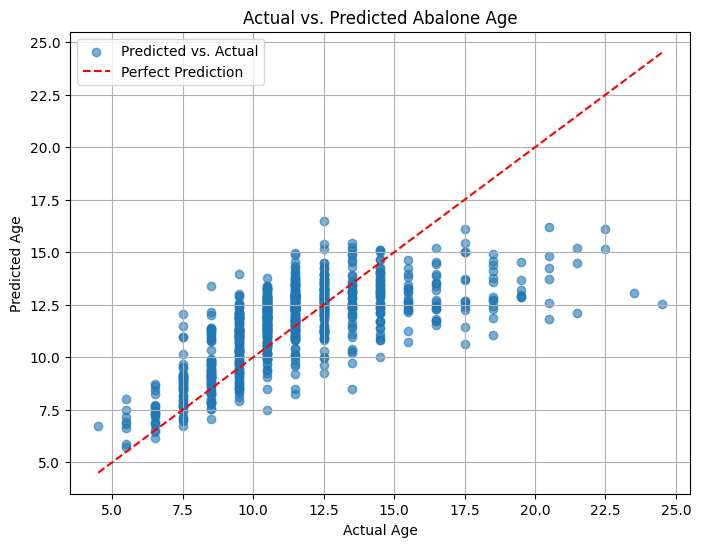

In [15]:
import matplotlib.pyplot as plt

# Flatten y_test and y_pred for plotting if they are 2D arrays with a single column
y_test_flat = y_test.flatten()
y_pred_flat = y_pred.flatten()

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test_flat, y_pred_flat, alpha=0.6, label='Predicted vs. Actual')

# Add a diagonal line for perfect predictions
# Determine the range for the diagonal line
min_val = min(y_test_flat.min(), y_pred_flat.min())
max_val = max(y_test_flat.max(), y_pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

# Label the axes
plt.xlabel('Actual Age')
plt.ylabel('Predicted Age')

# Add a title
plt.title('Actual vs. Predicted Abalone Age')

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()